# Predicting Parkinson's Disease Severity from Biomedical Voice Measurements

## Project Overview

Parkinson's disease is a progressive neurological disorder that can affect movement, speech and other aspects of daily functioning. Changes in speech and voice may provide measurable information related to disease severity, creating potential opportunities for non-invasive symptom monitoring.

This project investigates whether biomedical voice measurements can be used to predict motor symptom severity in people with Parkinson's disease. Motor symptom severity is represented by the Motor Unified Parkinson's Disease Rating Scale (Motor UPDRS).

The project uses exploratory data analysis and machine-learning regression models to investigate relationships between voice characteristics and Motor UPDRS. Particular attention is given to participant-level data leakage because multiple voice recordings were collected from each participant.

### Research Question

**Can biomedical voice features predict the severity of Parkinson's disease motor symptoms, as measured by Motor UPDRS?**

### Approach

The analysis includes:
- Exploratory data analysis of participant characteristics, voice measurements and Motor UPDRS.
- Investigation of correlations and redundant voice features.
- Participant-grouped train/test splitting to prevent data leakage between repeated recordings from the same individual.
- Comparison of a mean baseline, Linear Regression and Random Forest regression.
- Five-fold participant-grouped cross-validation.
- Random Forest feature-importance analysis.
- Random Forest hyperparameter tuning.
- Discussion of limitations and ethical considerations.

### Dataset source

Tsanas, A. & Little, M. (2009). *Parkinsons Telemonitoring* [Dataset]. UCI Machine Learning Repository.
- [UCI Machine Learning Repository - Parkinsons Telemonitoring](https://archive.ics.uci.edu/dataset/189/parkinson)
-[Dataset DOI: 10.24432/C5ZS3N](https://doi.org/10.24432/C5ZS3N)

### Original Study
Tsanas, A., Little, M. A., McSharry, P. E. & Ramig, L. O. (2010).
*Accurate telemonitoring of Parkinson's disease progression by non-invasive speech tests*.
IEEE Transactions on Biomedical Engineering, 57(4), 884-893.
[Original study DOI: 10.1109/TBME.2009.2036000](https://DOI.ORG/10.1109/TBME.2009.2036000)

The dataset was collected during a six-month telemonitoring study involving 42 people with early-stage Parkinson's disease.

Participants provided repeated voice recordings, producing 5,875 observations. Each recording contains biomedical voice measurements alongside participant information and clinical measures of Parkinson's disease severity.

The target variable used in this project is **`motor_UPDRS`**, a continuous measure of motor symptom severity. Higher Motor UPDRS values indicate greater motor impairment.

As each participant contributed multiple recordings, the observations are not completely independent. Participant identity therefore needs to be considered when splitting the data for model evaluation.



## 1. Data Loading and Initial Inspection

In [289]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [290]:
df = pd.read_csv("parkinsons_updrs.data")


In [291]:
df.head()


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [292]:
df.shape

(5875, 22)

In [293]:
df["subject#"].nunique()

42

In [294]:
df["subject#"].value_counts().sort_index()

,count
subject#,
1,149
2,145
3,144
4,137
5,156
6,156
7,161
8,150
9,152


In [295]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18  HNR     

In [296]:
df.describe()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,21.494128,64.804936,0.317787,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,12.372279,8.821524,0.465656,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,1.000000,36.000000,0.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,10.000000,58.000000,0.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,22.000000,65.000000,0.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,33.000000,72.000000,1.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,42.000000,85.000000,1.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


### Initial Observations

- The dataset contains **5,875 voice recordings and 22 variables**.
- These recordings were collected from only **42 participants**, meaning that individual participants contributed multiple observations.
- No missing values were identified in the dataset.
- `motor_UPDRS` is used as the regression target because it represents motor symptom severity.
- `subject#` identifies participants and should not be treated as a predictive feature.
- `total_UPDRS` is another clinical severity measure and is excluded from the predictors to maintain a voice-based prediction task.

## 2. Exploratory Data Analysis

### Participant Demographics

Because participants contributed multiple voice recordings, demographic statistics were calculated using one observation per participant rather than across all 5,875 recordings.

In [297]:
participants = df.drop_duplicates(subset="subject#")

In [298]:
participants["age"].describe()

,age
count,42.000000
mean,64.404762
std,9.239521
min,36.000000
25%,58.000000
50%,65.000000
75%,72.000000
max,85.000000


In [299]:
participants["sex"].value_counts()

,count
sex,
0,28
1,14


In [300]:
participants["sex"].value_counts(normalize=True) * 100

,proportion
sex,
0,66.666667
1,33.333333


The dataset contains 42 participants with a mean age of approximately 64.4 years (SD = 9.24), ranging from 36 to 85 years. Of the participants, 28 (66.7%) were male and 14 (33.3%) were female.

The relatively small number of participants and imbalance in sex distribution should be considered when assessing the generalisability of the models.

### Distribution of Motor UPDRS

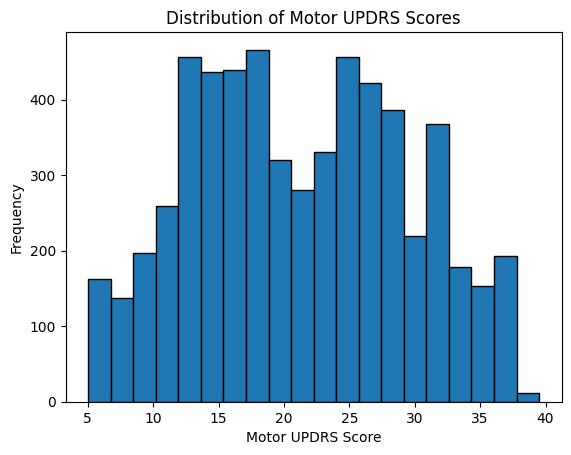

In [301]:
plt.hist(df["motor_UPDRS"], bins=20, edgecolor="black")
plt.xlabel("Motor UPDRS Score")
plt.ylabel("Frequency")
plt.title("Distribution of Motor UPDRS Scores")
plt.show()

Motor UPDRS values span a broad range of symptom severity. The distribution is not strongly skewed, although it is uneven rather than following a smooth normal distribution. These values represent repeated observations from participants and should therefore not be interpreted as 5,875 independent measurements of different individuals.

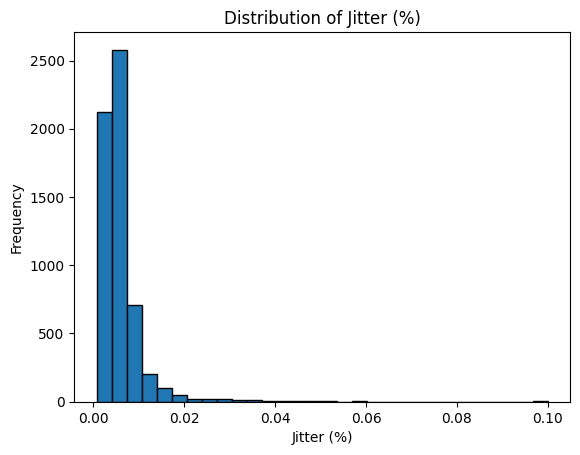

In [302]:
plt.hist(df["Jitter(%)"], bins=30, edgecolor="black")
plt.xlabel("Jitter (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Jitter (%)")
plt.show()

`Jitter(%)` shows a strongly right-skewed distribution, with most recordings concentrated at relatively low values and a smaller number of much larger observations. This demonstrates that some voice measurements are not normally distributed and contain extreme values.

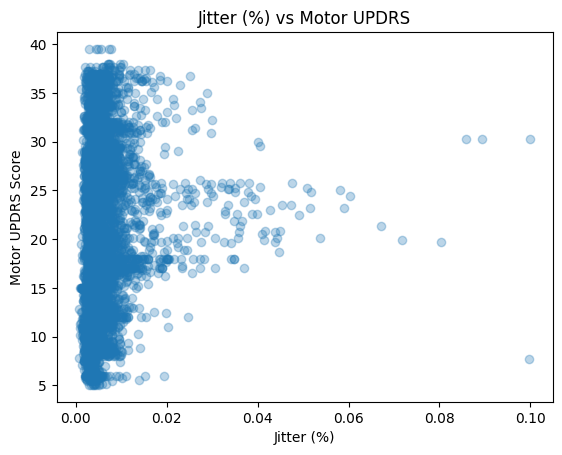

In [303]:
plt.scatter(df["Jitter(%)"], df["motor_UPDRS"], alpha= 0.3)
plt.xlabel("Jitter (%)")
plt.ylabel("Motor UPDRS Score")
plt.title("Jitter (%) vs Motor UPDRS")
plt.show()

In [304]:
df["Jitter(%)"].corr(df["motor_UPDRS"])

np.float64(0.08481575673063586)

In [305]:
correlation_matrix = df.corr()

In [306]:
motor_correlations = correlation_matrix["motor_UPDRS"].sort_values(ascending=False)
motor_correlations

,motor_UPDRS
motor_UPDRS,1.000000
total_UPDRS,0.947231
age,0.273665
subject#,0.252919
PPE,0.162433
Shimmer:APQ11,0.136560
RPDE,0.128607
Shimmer(dB),0.110076
Shimmer,0.102349
Shimmer:APQ5,0.092105


In [307]:
df[["Jitter:RAP", "Jitter:DDP"]].head(10)

,Jitter:RAP,Jitter:DDP
0,0.00401,0.01204
1,0.00132,0.00395
2,0.00205,0.00616
3,0.00191,0.00573
4,0.00093,0.00278
5,0.00119,0.00357
6,0.00212,0.00637
7,0.00226,0.00678
8,0.00156,0.00468
9,0.00258,0.00773


In [308]:
(df["Jitter:DDP"] / df["Jitter:RAP"]).describe()

,0
count,5875.000000
mean,3.000057
std,0.004698
min,2.969697
25%,2.997041
50%,3.000000
75%,3.003215
max,3.029412


In [309]:
df[["Shimmer:APQ3", "Shimmer:DDA"]].head(10)

,Shimmer:APQ3,Shimmer:DDA
0,0.01438,0.04314
1,0.00994,0.02982
2,0.00734,0.02202
3,0.01106,0.03317
4,0.00679,0.02036
5,0.01006,0.03019
6,0.02376,0.07128
7,0.00979,0.02937
8,0.01774,0.05323
9,0.02030,0.06089


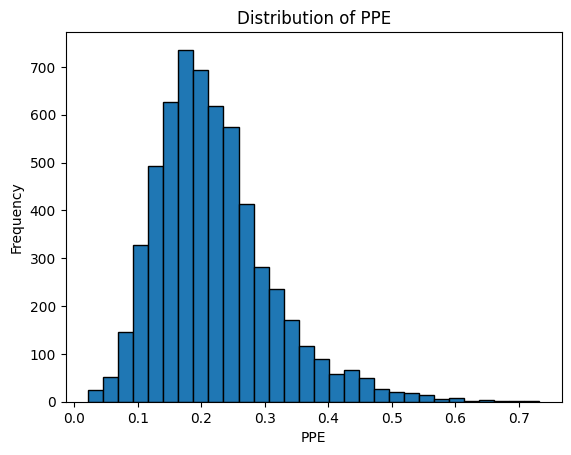

In [310]:
plt.hist(df["PPE"], bins=30, edgecolor="black")
plt.xlabel("PPE")
plt.ylabel("Frequency")
plt.title("Distribution of PPE")
plt.show()

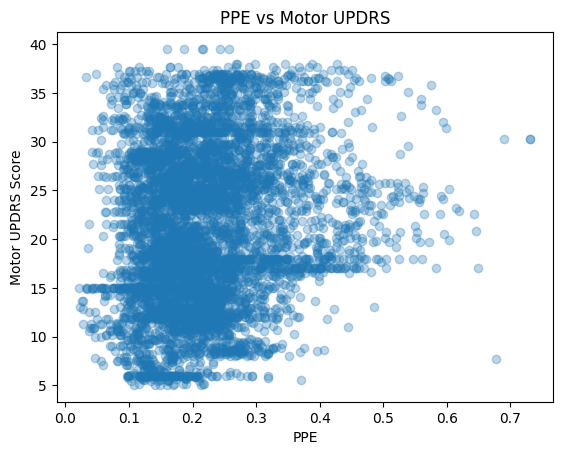

In [311]:
plt.scatter(df["PPE"], df["motor_UPDRS"], alpha=0.3)
plt.xlabel("PPE")
plt.ylabel("Motor UPDRS Score")
plt.title("PPE vs Motor UPDRS")
plt.show()

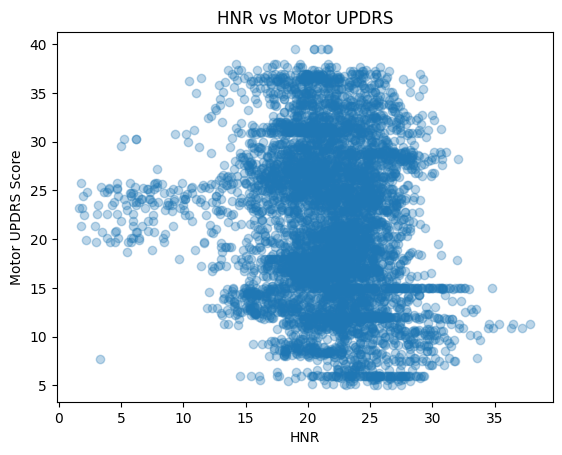

In [312]:
plt.scatter(df["HNR"], df["motor_UPDRS"], alpha=0.3)
plt.xlabel("HNR")
plt.ylabel("Motor UPDRS Score")
plt.title("HNR vs Motor UPDRS")
plt.show()

The scatterplots show substantial overlap in Motor UPDRS values across the voice measurements, with no strong simple linear relationships apparent. Jitter(%) in particular shows little association with Motor UPDRS, while PPE and HNR show slightly stronger but still weak relationships.

These observations suggest that individual voice measurements alone are unlikely to provide precise estimates of motor symptom severity. However, weak univariate relationships do not rule out the possibility that combinations of features, non-linear relationships or interactions between features may contain predictive information.

In [313]:
voice_correlations = correlation_matrix["motor_UPDRS"].drop(
    ["motor_UPDRS", "total_UPDRS", "subject#", "age", "sex", "test_time"]
    )
voice_correlations.abs().sort_values(ascending=False)

,motor_UPDRS
PPE,0.162433
HNR,0.157029
Shimmer:APQ11,0.136560
RPDE,0.128607
DFA,0.116242
Shimmer(dB),0.110076
Shimmer,0.102349
Shimmer:APQ5,0.092105
Jitter(%),0.084816
Shimmer:APQ3,0.084261


### Correlation Analysis

Individual voice features showed relatively weak linear correlations with Motor UPDRS. PPE had the strongest positive correlation among the selected voice measurements, while HNR and DFA showed weak negative correlations.

The relatively small correlation coefficients indicate that no individual voice feature has a strong linear relationship with motor symptom severity. Correlation only measures linear association and does not capture more complex relationships or interactions between multiple features.

In [314]:
voice_features = [
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE",

]

In [315]:
len(voice_features)

16

In [316]:
selected_voice_features = [
    feature for feature in voice_features
    if feature not in ["Jitter:DDP", "Shimmer:DDA"]
]

In [317]:
len(selected_voice_features)

14

In [318]:
selected_voice_features

['Jitter(%)',
 'Jitter(Abs)',
 'Jitter:RAP',
 'Jitter:PPQ5',
 'Shimmer',
 'Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'Shimmer:APQ11',
 'NHR',
 'HNR',
 'RPDE',
 'DFA',
 'PPE']

### Redundant Features

Several voice measurements were highly related. In particular, `Jitter:DDP` was approximately three times `Jitter:RAP`, while `Shimmer:DDA` was approximately three times `Shimmer:APQ3`. To reduce redundant information, `Jitter:DDP` and `Shimmer:DDA` were excluded from the final feature set.

## 3. Model Development and Evaluation

The aim of the modelling stage was to determine whether the selected biomedical voice features could predict Motor UPDRS severity in participants not seen during training.

Because each participant contributed multiple voice recordings, a conventional random train-test split could place recordings from the same participant in both sets. This could lead to data leakage and overly optimistic estimates of model performance.

Participant identity was therefore used as a grouping variable so that all recordings from a participant remained entirely within either the training or test set.

In [319]:
X = df[selected_voice_features]
y = df["motor_UPDRS"]

In [320]:
X.shape, y.shape

((5875, 14), (5875,))

In [321]:
groups = df["subject#"]

In [322]:
groups.nunique()

42

In [323]:
from sklearn.model_selection import GroupShuffleSplit

In [324]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

In [325]:
train_idx, test_idx = next(gss.split(X, y, groups=groups))

In [326]:
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [327]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print ("y_test:", y_test.shape)

X_train: (4640, 14)
X_test: (1235, 14)
y_train: (4640,)
y_test: (1235,)


In [328]:
train_subjects = groups.iloc[train_idx].unique()
test_subjects = groups.iloc[test_idx].unique()

In [329]:
print("Training participants:", len(train_subjects))
print("Test participants:", len(test_subjects))

Training participants: 33
Test participants: 9


In [330]:
set(train_subjects).intersection(set(test_subjects))

set()

### Participant-Grouped Train/Test Split

The data were split by participant rather than by individual recording. The training set contained 33 participants and the test set contained 9 participants, with no participant appearing in both sets.

This prevents the models from being evaluated on additional recordings from individuals they had already encountered during training and provides a more realistic assessment of generalisation to unseen participants.

### Linear Regression

Linear Regression was used as the first predictive model to investigate whether a linear combination of the selected biomedical voice features could predict Motor UPDRS.

In [331]:
from sklearn.linear_model import LinearRegression

In [332]:
linear_model = LinearRegression()

In [333]:
linear_model.fit(X_train, y_train)

LinearRegression()

In [334]:
y_pred = linear_model.predict(X_test)

In [335]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_mae = mean_absolute_error(y_test, y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_r2 = r2_score(y_test, y_pred)

print(f"MAE: {lr_mae:.2f}")
print (f"RMSE: {lr_rmse:.2f}")
print (f"R2: {lr_r2:.3f}")

MAE: 7.06
RMSE: 8.73
R2: -0.306


#### Interpretation

Linear Regression achieved an MAE of approximately 7.06 Motor UPDRS points and an RMSE of 8.73. The negative R² value (-0.306) indicates that the model performed poorly on the held-out participants and did not explain the variation in Motor UPDRS effectively.

These results suggest that a simple linear combination of the selected biomedical voice features does not generalise well to unseen participants.

### Baseline Model

A mean baseline model was used as a simple reference for evaluating the machine-learning models. The baseline predicts the mean Motor UPDRS value from the training data for every observation in the test set.

Comparing the machine-learning models against this baseline helps determine whether they provide meaningful predictive improvement over a simple constant prediction.

In [336]:
from sklearn.dummy import DummyRegressor

baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

In [337]:
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print (f"Baseline R2: {baseline_r2:.3f}")

Baseline MAE: 6.91
Baseline RMSE: 7.82
Baseline R2: -0.048


#### Interpretation

The mean baseline achieved an MAE of approximately 6.91 and an RMSE of 7.82. Linear Regression performed worse than the baseline across the evaluation metrics, indicating that the linear model did not provide an improvement over simply predicting the training-set mean for these held-out participants.

This highlights the importance of comparing machine-learning models against a simple baseline rather than assessing their performance in isolation.

### Random Forest Regression

Random Forest was used to investigate whether non-linear relationships and interactions between the biomedical voice features could improve prediction of Motor UPDRS compared with Linear Regression.

In [338]:
from sklearn.ensemble import RandomForestRegressor

In [339]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [340]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [341]:
rf_pred = rf_model.predict(X_test)

In [342]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R2: {rf_r2:.3f}")


Random Forest MAE: 6.76
Random Forest RMSE: 8.03
Random Forest R2: -0.105


#### Interpretation

Random Forest achieved an MAE of approximately 6.76 and an RMSE of 8.03, performing better than Linear Regression on this train-test split. Its MAE was also slightly lower than the mean baseline.

However, the Random Forest still produced a negative R² and its overall performance remained close to the baseline. Therefore, the results from this single train-test split do not provide strong evidence that Random Forest can reliably predict Motor UPDRS for unseen participants.

Because performance may depend on which participants are included in the test set, participant-grouped cross-validation is used later to provide a more robust comparison between the models.

### Random Forest Diagnostic Analysis

To better understand the Random Forest's prediction errors, actual Motor UPDRS values were compared with the model's predicted values.

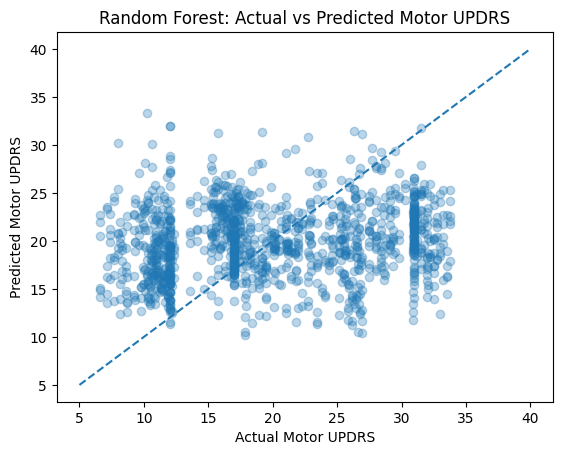

In [343]:
plt.scatter(y_test, rf_pred, alpha=0.3)

plt.plot([5, 40], [5,40], linestyle="--")

plt.xlabel("Actual Motor UPDRS")
plt.ylabel("Predicted Motor UPDRS")
plt.title("Random Forest: Actual vs Predicted Motor UPDRS")

plt.show()

#### Actual vs Predicted Values

The predictions show substantial scatter rather than closely following the perfect-prediction line. Predictions are also concentrated within a narrower range than the actual Motor UPDRS values.

The model tends to overpredict some lower severity scores and underpredict some higher severity scores, suggesting that it has difficulty predicting more extreme levels of motor symptom severity. This helps explain why the Random Forest achieved only limited improvement over the baseline model.

In [344]:
rf_residuals = y_test.values - rf_pred

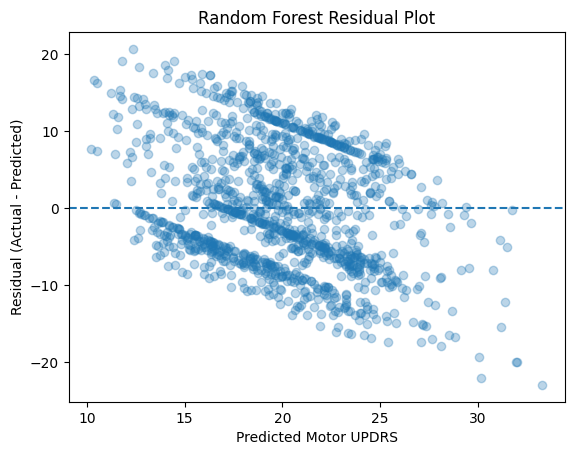

In [345]:
plt.scatter(rf_pred, rf_residuals, alpha=0.3)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Motor UPDRS")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Random Forest Residual Plot")

plt.show()

#### Residual Analysis

Residuals were calculated as the difference between the actual and predicted Motor UPDRS values. Positive residuals therefore represent underprediction, while negative residuals represent overprediction.

The residuals are not randomly distributed around zero and instead show noticeable structure and several relatively large errors. This indicates that the Random Forest is not capturing all of the patterns associated with Motor UPDRS and supports the limited predictive performance observed in the evaluation metrics.

The diagonal patterns may partly reflect the repeated-measures structure of the dataset, where multiple related observations originate from the same participants.

## 4. Participant-Grouped Cross-Validation

The initial train-test split provides only one estimate of model performance and may depend strongly on which participants happen to be included in the test set.

To obtain a more robust estimate of generalisation, five-fold GroupKFold cross-validation was used. Participants were treated as groups so that recordings from the same participant could not appear in both the training and validation sets within a fold.

In each fold, the model was trained on one group of participants and evaluated on participants it had not seen during training. Performance was assessed using MAE, RMSE and R².

In [346]:
from sklearn.model_selection import GroupKFold

In [347]:
gkf = GroupKFold(n_splits=5)

In [348]:
for fold, (train_idx_cv, test_idx_cv) in enumerate(
  gkf.split(X, y, groups=groups),
  start=1
):
  train_ids = set(groups.iloc[train_idx_cv])
  test_ids = set(groups.iloc[test_idx_cv])

  overlap = train_ids.intersection(test_ids)

  print(f"Fold {fold} overlap:", overlap)

Fold 1 overlap: set()
Fold 2 overlap: set()
Fold 3 overlap: set()
Fold 4 overlap: set()
Fold 5 overlap: set()


The overlap check confirmed that no participant appeared in both the training and validation sets within any fold, reducing the risk of participant-level data leakage.

In [349]:
lr_mae_scores = []
lr_rmse_scores = []
lr_r2_scores = []

In [350]:
for fold, (train_idx_cv, test_idx_cv) in enumerate(gkf.split(X, y, groups=groups), start=1):

 X_train_cv = X.iloc[train_idx_cv]
 X_test_cv = X.iloc[test_idx_cv]

 y_train_cv = y.iloc[train_idx_cv]
 y_test_cv = y.iloc[test_idx_cv]

 model = LinearRegression()
 model.fit(X_train_cv, y_train_cv)

 pred_cv = model.predict(X_test_cv)

 mae_cv = mean_absolute_error(y_test_cv, pred_cv)
 rmse_cv = np.sqrt(mean_squared_error(y_test_cv, pred_cv))
 r2_cv = r2_score(y_test_cv, pred_cv)

 lr_mae_scores.append(mae_cv)
 lr_rmse_scores.append(rmse_cv)
 lr_r2_scores.append(r2_cv)

 print(
     f"Fold {fold}: "
     f"MAE={mae_cv:.2f},"
     f"RMSE={rmse_cv:.2f}, "
     f"R2={r2_cv:.3f}"
 )

Fold 1: MAE=7.05,RMSE=8.29, R2=-0.865
Fold 2: MAE=6.41,RMSE=7.51, R2=0.049
Fold 3: MAE=8.09,RMSE=10.78, R2=-0.576
Fold 4: MAE=6.30,RMSE=7.52, R2=-0.015
Fold 5: MAE=9.00,RMSE=9.51, R2=-0.329


In [351]:
print("Linear Regression Cross-Validation")

print(f"Mean MAE: {np.mean(lr_mae_scores): .2f} ± {np.std(lr_mae_scores): .2f}")
print(f"Mean RMSE: {np.mean(lr_rmse_scores): .2f} ± {np.std(lr_rmse_scores): .2f}")
print(f"Mean R2: {np.mean(lr_r2_scores): .3f} ± {np.std(lr_r2_scores): .3f}")

Linear Regression Cross-Validation
Mean MAE:  7.37 ±  1.03
Mean RMSE:  8.72 ±  1.26
Mean R2: -0.347 ±  0.343


#### Linear Regression Cross-Validation Results

Across the five participant-grouped folds, Linear Regression achieved a mean MAE of 7.37 ± 1.03 and a mean RMSE of 8.72 ± 1.26. The mean R² was -0.347 ± 0.343.

The variation between folds indicates that model performance depended considerably on which participants were held out for evaluation. The negative mean R² suggests that Linear Regression did not generalise effectively to unseen participants.

In [352]:
rf_mae_scores = []
rf_rmse_scores = []
rf_r2_scores = []

In [353]:
for fold, (train_idx_cv, test_idx_cv) in enumerate(gkf.split(X, y, groups=groups), start=1):

  X_train_cv = X.iloc[train_idx_cv]
  X_test_cv = X.iloc[test_idx_cv]

  y_train_cv = y.iloc[train_idx_cv]
  y_test_cv = y.iloc[test_idx_cv]

  model = RandomForestRegressor(n_estimators=100, random_state=42)

  model.fit(X_train_cv, y_train_cv)

  pred_cv = model.predict(X_test_cv)

  mae_cv = mean_absolute_error(y_test_cv, pred_cv)
  rmse_cv = np.sqrt(mean_squared_error(y_test_cv, pred_cv))
  r2_cv = r2_score(y_test_cv, pred_cv)

  rf_mae_scores.append(mae_cv)
  rf_rmse_scores.append(rmse_cv)
  rf_r2_scores.append(r2_cv)

  print(f"Fold {fold}: MAE={mae_cv:.2f}, RMSE={rmse_cv:.2f}, R2={r2_cv:.3f}")

Fold 1: MAE=7.32, RMSE=8.83, R2=-1.117
Fold 2: MAE=6.90, RMSE=8.15, R2=-0.120
Fold 3: MAE=7.57, RMSE=9.63, R2=-0.259
Fold 4: MAE=6.79, RMSE=8.42, R2=-0.273
Fold 5: MAE=8.67, RMSE=9.48, R2=-0.320


In [354]:
print ("Random Forest Cross-Validation")

print(f"Mean MAE: {np.mean(rf_mae_scores): .2f} ± {np.std(rf_mae_scores): .2f}")
print(f"Mean RMSE: {np.mean(rf_rmse_scores): .2f} ± {np.std(rf_rmse_scores): .2f}")
print(f"Mean R2: {np.mean(rf_r2_scores): .3f} ± {np.std(rf_r2_scores): .3f}")


Random Forest Cross-Validation
Mean MAE:  7.45 ±  0.67
Mean RMSE:  8.90 ±  0.58
Mean R2: -0.418 ±  0.356


#### Random Forest Cross-Validation Results

Across the five participant-grouped folds, Random Forest achieved a mean MAE of 7.45 ± 0.67 and a mean RMSE of 8.90 ± 0.58. The mean R² was -0.418 ± 0.356.

Although Random Forest had performed slightly better than Linear Regression on the initial train-test split, this advantage did not persist across participant-grouped cross-validation. This demonstrates why evaluating the models across multiple groups of unseen participants is more informative than relying on a single train-test split.

In [355]:
baseline_mae_scores = []
baseline_rmse_scores = []
baseline_r2_scores = []

In [356]:
for fold, (train_idx_cv, test_idx_cv) in enumerate(gkf.split(X, y, groups=groups), start=1):

  X_train_cv = X.iloc[train_idx_cv]
  X_test_cv = X.iloc[test_idx_cv]
  y_train_cv = y.iloc[train_idx_cv]
  y_test_cv = y.iloc[test_idx_cv]

  model = DummyRegressor(strategy="mean")

  model.fit(X_train_cv, y_train_cv)

  pred_cv = model.predict(X_test_cv)

  mae_cv = mean_absolute_error(y_test_cv, pred_cv)
  rmse_cv = np.sqrt(mean_squared_error(y_test_cv, pred_cv))
  r2_cv = r2_score(y_test_cv, pred_cv)

  baseline_mae_scores.append(mae_cv)
  baseline_rmse_scores.append(rmse_cv)
  baseline_r2_scores.append(r2_cv)

  print(f"Fold {fold}: MAE={mae_cv:.2f}, RMSE={rmse_cv:.2f}, R2={r2_cv:.3f}")







Fold 1: MAE=6.88, RMSE=7.89, R2=-0.690
Fold 2: MAE=6.54, RMSE=7.80, R2=-0.026
Fold 3: MAE=7.11, RMSE=8.70, R2=-0.027
Fold 4: MAE=6.19, RMSE=7.48, R2=-0.005
Fold 5: MAE=9.25, RMSE=9.75, R2=-0.396


In [357]:
print("Baseline Cross-Validation")

print(f"Mean MAE: {np.mean(baseline_mae_scores):.2f} ± {np.std(baseline_mae_scores): .2f}")
print(f"Mean RMSE: {np.mean(baseline_rmse_scores):.2f} ± {np.std(baseline_rmse_scores): .2f}")
print(f"Mean R2: {np.mean(baseline_r2_scores): .3f} ± {np.std(baseline_r2_scores): .3f}")




Baseline Cross-Validation
Mean MAE: 7.19 ±  1.07
Mean RMSE: 8.32 ±  0.82
Mean R2: -0.229 ±  0.273


#### Baseline Cross-Validation Results

Across the five participant-grouped folds, the mean baseline achieved an MAE of 7.19 ± 1.07 and an RMSE of 8.32 ± 0.82, with a mean R² of -0.229 ± 0.273.

The baseline performed slightly better overall than both Linear Regression and Random Forest. This indicates that neither machine-learning model consistently provided improved predictions of Motor UPDRS for unseen participants.

### Cross-Validation Model Comparison

In [358]:
cv_results = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        f"{np.mean(baseline_mae_scores):.2f} ± {np.std(baseline_mae_scores):.2f}",
        f"{np.mean(lr_mae_scores):.2f} ± {np.std(lr_mae_scores):.2f}",
        f"{np.mean(rf_mae_scores):.2f} ± {np.std(rf_mae_scores):.2f}"
    ],
    "RMSE": [
        f"{np.mean(baseline_rmse_scores):.2f} ± {np.std(baseline_rmse_scores):.2f}",
        f"{np.mean(lr_rmse_scores):.2f} ± {np.std(lr_rmse_scores):.2f}",
        f"{np.mean(rf_rmse_scores):.2f} ± {np.std(rf_rmse_scores):.2f}"
    ],
    "R2": [
         f"{np.mean(baseline_r2_scores):.3f} ± {np.std(baseline_r2_scores):.3f}",
         f"{np.mean(lr_r2_scores):.3f} ± {np.std(lr_r2_scores):.3f}",
         f"{np.mean(rf_r2_scores):.3f} ± {np.std(rf_r2_scores):.3f}"

    ]
})

cv_results


,Model,MAE,RMSE,R2
0,Mean Baseline,7.19 ± 1.07,8.32 ± 0.82,-0.229 ± 0.273
1,Linear Regression,7.37 ± 1.03,8.72 ± 1.26,-0.347 ± 0.343
2,Random Forest,7.45 ± 0.67,8.90 ± 0.58,-0.418 ± 0.356


#### Overall Model Comparison

Participant-grouped cross-validation showed that neither Linear Regression nor Random Forest consistently outperformed the mean baseline. Although Random Forest appeared slightly more promising on the initial train-test split, this advantage disappeared when performance was evaluated across multiple groups of unseen participants.

These results suggest that the selected biomedical voice features, when used with the modelling approaches investigated here, do not provide reliable improvement over a simple mean prediction for Motor UPDRS in unseen participants.

## 5. Random Forest Feature Importance

To investigate which voice measurements the Random Forest relied on most, a separate Random Forest was fitted using the full dataset and feature importances were extracted.

This model is used only for descriptive feature-importance analysis, not for evaluating predictive performance. Performance results are based on the participant-grouped validation presented above.

In [359]:
rf_final = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_final.fit(X, y)

RandomForestRegressor(random_state=42)

In [360]:
feature_importance = pd.Series(
    rf_final.feature_importances_,
    index=X.columns

)

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance

,0
DFA,0.153461
HNR,0.116365
PPE,0.102306
Jitter(Abs),0.101264
RPDE,0.090182
Shimmer:APQ11,0.070820
NHR,0.063298
Shimmer:APQ3,0.055458
Jitter:PPQ5,0.052189
Jitter:RAP,0.049171


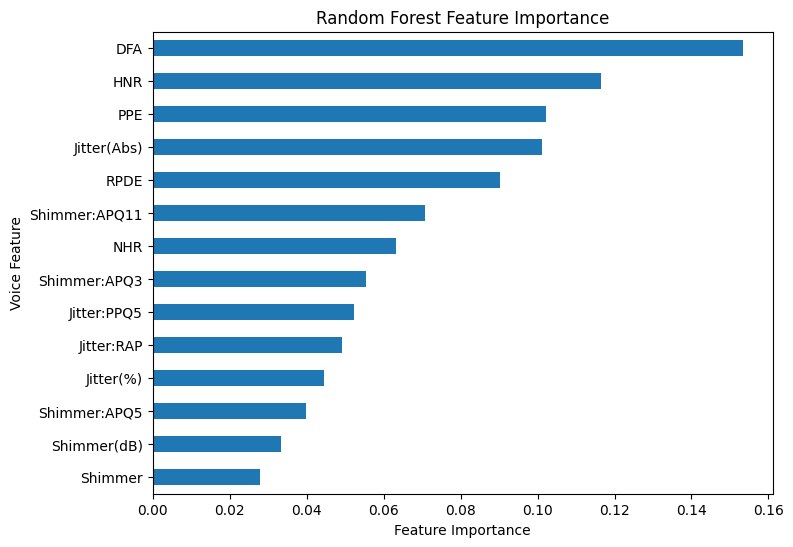

In [361]:
feature_importance.sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.xlabel("Feature Importance")
plt.ylabel("Voice Feature")
plt.title("Random Forest Feature Importance")
plt.show()

#### Interpretation

DFA had the highest Random Forest feature importance, followed by HNR, PPE, Jitter(Abs) and RPDE. This ranking differs somewhat from the earlier correlation analysis. For example, Jitter(Abs) showed only a weak individual linear correlation with Motor UPDRS but received relatively high importance within the Random Forest.

This may indicate that the Random Forest used non-linear relationships or interactions between multiple voice features that are not captured by simple correlation analysis.

However, these importance values should be interpreted cautiously. Random Forest feature importance does not indicate causation or show whether a feature increases or decreases predicted severity. Correlations between predictors can also affect the importance assigned to individual features. Most importantly, the Random Forest showed limited generalisation to unseen participants, so these results should not be interpreted as evidence that the highest-ranked features are reliable clinical biomarkers.

## Random Forest Hyperparameter Tuning

The initial Random Forest used largely default hyperparameter settings. A small grid search was therefore performed to investigate whether controlling model complexity could improve generalisation.

Hyperparameters were selected using participant-grouped cross-validation on the training data only. The held-out test participants were not used during hyperparameter selection.

In [362]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_leaf": [2, 4]
}

In [363]:
from sklearn.model_selection import GridSearchCV

In [364]:
tuning_cv = GroupKFold(n_splits=5)

In [365]:
rf_tuning = RandomForestRegressor(
    random_state=42
)

In [366]:
grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=tuning_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

In [367]:
grid_search.fit(
    X_train,
    y_train,
    groups=groups.iloc[train_idx]
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'min_samples_leaf': [2, 4],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_absolute_error', verbose=1)

In [368]:
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}


In [369]:
best_cv_mae = -grid_search.best_score_

print("Best CV MAE:", best_cv_mae)

Best CV MAE: 7.440456674377481


In [370]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}
-7.440456674377481


In [371]:
print(grid_search.cv_results_["mean_test_score"])

[-7.45207241 -7.44045667 -7.46301243 -7.45787681 -7.473848   -7.46438943
 -7.4617043  -7.46094346]


In [372]:
print(y_train.describe())

count    4640.000000
mean       21.646407
std         8.220281
min         5.037700
25%        15.000000
50%        21.557500
75%        27.739000
max        39.511000
Name: motor_UPDRS, dtype: float64


In [373]:
print("X_train rows:", len(X_train))
print("y_train rows:", len(y_train))
print("group rows:", len(groups.iloc[train_idx]))

print("\nX_train first indices:")
print(X_train.index[:5])

print("\nGroup first indices:")
print(groups.iloc[train_idx].index[:5])

X_train rows: 4640
y_train rows: 4640
group rows: 4640

X_train first indices:
Index([0, 1, 2, 3, 4], dtype='int64')

Group first indices:
Index([0, 1, 2, 3, 4], dtype='int64')


In [374]:
print(grid_search.scoring)

neg_mean_absolute_error


In [375]:
print(grid_search.best_estimator_)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, n_estimators=200,
                      random_state=42)


In [376]:
best_rf = grid_search.best_estimator_

In [377]:
tuned_rf_pred = best_rf.predict(X_test)

In [378]:
tuned_rf_mae = mean_absolute_error(y_test, tuned_rf_pred)

tuned_rf_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_rf_pred)
)

tuned_rf_r2 = r2_score(y_test, tuned_rf_pred)


print("Tuned RF MAE:", tuned_rf_mae)
print("Tuned RF RMSE:", tuned_rf_rmse)
print("Tuned RF R2:", tuned_rf_r2)

Tuned RF MAE: 6.811737766303487
Tuned RF RMSE: 8.017362574402766
Tuned RF R2: -0.10244572950027564


#### Interpretation

The grouped grid search selected a more constrained Random Forest, including a maximum tree depth of 10 and a minimum of 2 samples per leaf. However, hyperparameter tuning produced little change in performance on the held-out participants.

The tuned Random Forest achieved an MAE of 6.81, RMSE of 8.02 and R² of -0.102, compared with an MAE of 6.76, RMSE of 8.03 and R² of -0.105 for the original Random Forest.

These differences are very small and do not indicate a meaningful improvement from tuning. This suggests that the Random Forest's limited generalisation is unlikely to be explained solely by its original hyperparameter settings.

## Limitations

Several limitations should be considered when interpreting the results of this project.

* Firstly, although the dataset contained 5,875 voice recordings, these were collected from only 42 participants. Each participant contributed multiple recordings, meaning that the number of independent individuals was considerably smaller than the number of observations. This limits the diversity of participants available for model training and may contribute to the variation in performance observed when predicting symptom severity for unseen participants. Participant-grouped validation was therefore used to reduce the risk of data leakage.

* Secondly, the participant sample was relatively small and demographically imbalanced. Of the 42 participants, 28 (66.7%) were male and 14 (33.3%) were female. The dataset also consisted of individuals with early-stage Parkinson's disease. Consequently, the results may not generalise equally well across different demographic groups, disease stages, or the wider Parkinson's disease population.

* Individual voice features generally showed weak linear correlations with Motor UPDRS. This suggests that no single voice measurement had a strong linear relationship with symptom severity in this dataset. Although Random Forest can capture non-linear relationships and interactions between features, neither Linear Regression nor Random Forest consistently outperformed the mean baseline during participant-grouped cross-validation.

* Only two machine-learning approaches were investigated: Linear Regression and Random Forest. Hyperparameter tuning of the Random Forest produced little improvement in held-out test performance, but this does not demonstrate that voice measurements cannot be used to predict Parkinson's severity. Other modelling approaches, feature-engineering techniques, longitudinal methods, or larger datasets may produce different results.

* Several voice measurements were strongly correlated with one another. Highly redundant features were removed during feature selection, but correlations remained between some predictors. This should be considered when interpreting model behaviour and Random Forest feature importance, as importance within the fitted model does not necessarily indicate that a feature is independently associated with symptom severity.

* The longitudinal structure of the dataset presents an additional modelling challenge. Grouped validation prevented recordings from the same participant appearing in both the training and validation sets, but the models did not explicitly model changes in symptom severity over time within individuals. Longitudinal or mixed-effects modelling approaches could be investigated in future work.

* Motor UPDRS values associated with the voice recordings were derived using linear interpolation between clinical assessment visits rather than from a separate clinical assessment performed at the exact time of every voice recording. This introduces uncertainty into the target variable because some severity values are estimates between observed clinical assessments.

* Finally, the models were not externally validated using an independent dataset. Therefore, their performance cannot be assumed to generalise to Parkinson's patients outside the population represented in this study. Further research using larger and more diverse participant samples and independent validation data would be required before considering clinical applications.

## Ethical Considerations

Voice recordings and clinical severity scores represent sensitive health-related data. Voice data may also contain information beyond the measurements required for symptom monitoring and could potentially contribute to identifying an individual. Any real-world system using this type of data would therefore require informed consent, appropriate anonymisation, secure data storage, controlled access, and protection of patient privacy.

Bias and representativeness are also important considerations. The dataset contained a relatively small and demographically imbalanced participant sample, meaning that model performance may differ across populations that are underrepresented in the data. Deploying a model without evaluating these differences could result in less reliable predictions for certain groups. Any future system should therefore be evaluated using larger and more diverse populations and should assess performance across relevant demographic groups.

The models developed in this project did not demonstrate sufficiently reliable performance on unseen participants for clinical application. Inaccurate estimates of symptom severity could lead to misleading interpretations of a patient's condition if predictions were relied upon without appropriate clinical oversight. Model performance and uncertainty would therefore need to be clearly communicated to both patients and healthcare professionals.

Finally, the purpose of the models in this project is to estimate motor symptom severity in people with Parkinson's disease, rather than to diagnose Parkinson's disease itself. A future voice-based system should not replace assessment by qualified healthcare professionals. If sufficiently validated, this type of technology may be more appropriate as a supportive monitoring tool used alongside clinical assessment rather than as a standalone diagnostic or clinical decision-making system.

## Conclusion

This project investigated whether biomedical voice measurements could be used to predict Parkinson's motor symptom severity, measured using Motor UPDRS.

Exploratory analysis found that individual voice features generally had weak linear relationships with Motor UPDRS. Features including PPE, HNR, RPDE and DFA showed some association with symptom severity, while highly redundant voice measurements were identified and removed before modelling.

Linear Regression and Random Forest models were evaluated using participant-grouped validation to prevent recordings from the same participant appearing in both training and validation data. Across five-fold grouped cross-validation, the mean baseline achieved an MAE of 7.19, compared with 7.37 for Linear Regression and 7.45 for Random Forest. Neither machine-learning model therefore consistently improved upon the simple mean baseline when predicting Motor UPDRS for unseen participants.

Random Forest hyperparameter tuning produced little improvement in held-out test performance, suggesting that the model's limited generalisation was unlikely to be explained solely by its original hyperparameter settings. Feature-importance analysis identified DFA, HNR, PPE, Jitter(Abs) and RPDE as the features the fitted Random Forest relied on most. However, these importance values should be interpreted cautiously because the model itself did not demonstrate strong generalisation to unseen participants.

Overall, the results do not provide evidence that the modelling approaches investigated can reliably predict Motor UPDRS for unseen participants using the selected biomedical voice measurements. However, this does not demonstrate that voice data have no predictive value for Parkinson's symptom monitoring. The relatively small participant sample, repeated-measures structure and limited range of modelling approaches mean that further investigation is required.

Future work could use larger and more diverse participant samples, external validation datasets, alternative machine-learning approaches and models designed specifically for longitudinal data. These would help determine whether changes in voice measurements could contribute to reliable, non-invasive monitoring of Parkinson's motor symptom severity.